Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2484
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0712
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0275
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0050
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.9223e-04
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.6740e-04
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.7080e-04
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.8490e-04
Epoch 9/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.1957e-04
Epoch 10/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.3052e-04
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


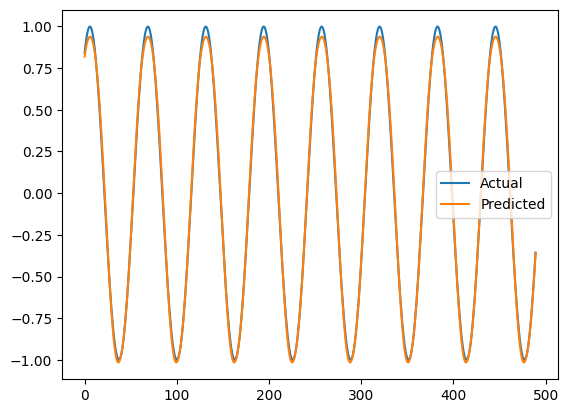

In [1]:
# Time Series Forecasting using RNN

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from sklearn.preprocessing import MinMaxScaler

# Generate data
data = np.sin(np.arange(0, 50, 0.1)).reshape(-1, 1)

# Normalize data
scaler = MinMaxScaler()
data = scaler.fit_transform(data)

# Create sequences
x, y = [], []
for i in range(10, len(data)):
    x.append(data[i-10:i])
    y.append(data[i])

x, y = np.array(x), np.array(y)

# Build RNN model
model = Sequential([
    SimpleRNN(20, input_shape=(10, 1)),
    Dense(1)
])

# Compile model
model.compile(optimizer='adam', loss='mse')

# Train model
model.fit(x, y, epochs=10, batch_size=16)

# Predict
pred = model.predict(x)

# Plot results
plt.plot(scaler.inverse_transform(y), label='Actual')
plt.plot(scaler.inverse_transform(pred), label='Predicted')
plt.legend()
plt.show()